<a href="https://colab.research.google.com/github/2403a52026-lgtm/NLP.LabAssignments/blob/main/NPL_LAB_05_2403a52026_B_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install spacy pandas matplotlib seaborn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [17]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/arxiv_data.csv")

# Display columns
print(df.columns)

# Select abstracts column (adjust name if needed)
abstracts = df['summaries'].dropna().tolist()

print("Total abstracts loaded:", len(abstracts))

Index(['titles', 'summaries', 'terms'], dtype='object')
Total abstracts loaded: 51774


In [18]:
import spacy

nlp = spacy.load("en_core_web_sm")


In [19]:
docs = list(nlp.pipe(abstracts[:500]))  # limit for performance


In [20]:
from collections import Counter

noun_phrases = []

for doc in docs:
    for chunk in doc.noun_chunks:
        noun_phrases.append(chunk.text.lower())

np_freq = Counter(noun_phrases)

# Top 20 noun phrases
top_noun_phrases = np_freq.most_common(20)
top_noun_phrases


[('we', 1295),
 ('which', 425),
 ('that', 326),
 ('it', 281),
 ('this paper', 195),
 ('the-art', 191),
 ('image segmentation', 148),
 ('our method', 115),
 ('-', 99),
 ('this work', 98),
 ('training', 75),
 ('segmentation', 75),
 ('semantic segmentation', 70),
 ('this', 63),
 ('images', 62),
 ('medical image segmentation', 58),
 ('they', 56),
 ('the performance', 52),
 ('our approach', 51),
 ('the proposed method', 44)]

In [21]:
entity_list = []

for doc in docs:
    for ent in doc.ents:
        entity_list.append((ent.text, ent.label_))

entity_freq = Counter(entity_list)
entity_freq.most_common(15)


[(('two', 'CARDINAL'), 195),
 (('three', 'CARDINAL'), 70),
 (('first', 'ORDINAL'), 70),
 (('CNN', 'ORG'), 64),
 (('one', 'CARDINAL'), 54),
 (('3D', 'ORG'), 53),
 (('U-Net', 'ORG'), 51),
 (('2D', 'CARDINAL'), 45),
 (('1', 'CARDINAL'), 41),
 (('2', 'CARDINAL'), 37),
 (('CT', 'ORG'), 32),
 (('four', 'CARDINAL'), 29),
 (('UDA', 'ORG'), 21),
 (('NAS', 'ORG'), 19),
 (('First', 'ORDINAL'), 18)]

In [22]:
entity_labels = [ent[1] for ent in entity_list]
label_freq = Counter(entity_labels)
label_freq


Counter({'DATE': 80,
         'GPE': 113,
         'CARDINAL': 761,
         'NORP': 68,
         'ORG': 1353,
         'ORDINAL': 143,
         'WORK_OF_ART': 16,
         'PERSON': 184,
         'PERCENT': 150,
         'PRODUCT': 35,
         'MONEY': 26,
         'TIME': 7,
         'LOC': 7,
         'LAW': 4,
         'EVENT': 2,
         'FAC': 14,
         'QUANTITY': 9})

In [23]:
from spacy.matcher import Matcher

matcher = Matcher(nlp.vocab)

# Pattern: Adjective + Noun (e.g., deep learning, neural network)
pattern1 = [
    {"POS": "ADJ"},
    {"POS": "NOUN"}
]

# Pattern: Noun + Noun (e.g., machine learning)
pattern2 = [
    {"POS": "NOUN"},
    {"POS": "NOUN"}
]

matcher.add("TECH_TERMS", [pattern1, pattern2])

matches_found = []

for doc in docs:
    matches = matcher(doc)
    for match_id, start, end in matches:
        matches_found.append(doc[start:end].text.lower())

Counter(matches_found).most_common(20)


[('image segmentation', 525),
 ('medical image', 202),
 ('semantic segmentation', 122),
 ('deep learning', 117),
 ('neural networks', 77),
 ('segmentation tasks', 69),
 ('neural network', 58),
 ('experimental results', 56),
 ('computer vision', 51),
 ('medical images', 50),
 ('training data', 45),
 ('supervised learning', 44),
 ('unlabeled data', 41),
 ('semantic image', 41),
 ('medical imaging', 39),
 ('segmentation methods', 39),
 ('segmentation model', 39),
 ('segmentation task', 38),
 ('extensive experiments', 38),
 ('segmentation models', 34)]

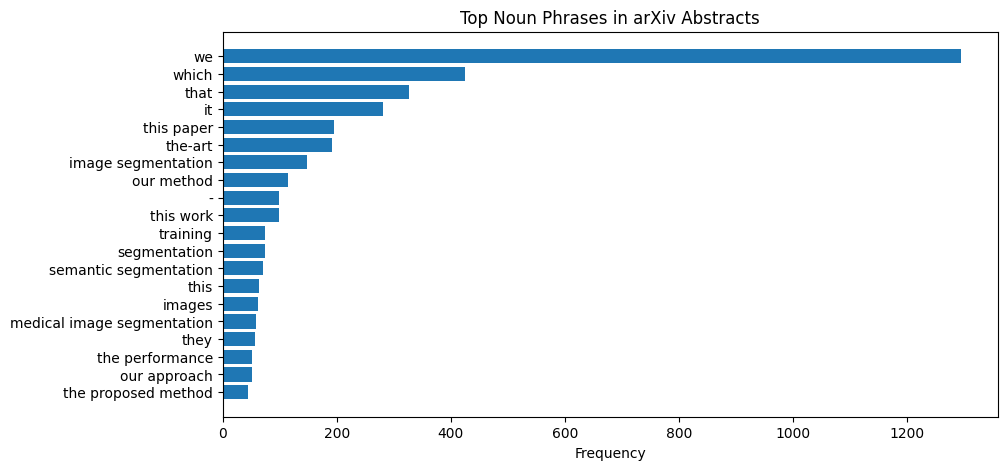

In [24]:
import matplotlib.pyplot as plt

phrases, counts = zip(*top_noun_phrases)

plt.figure(figsize=(10,5))
plt.barh(phrases, counts)
plt.xlabel("Frequency")
plt.title("Top Noun Phrases in arXiv Abstracts")
plt.gca().invert_yaxis()
plt.show()


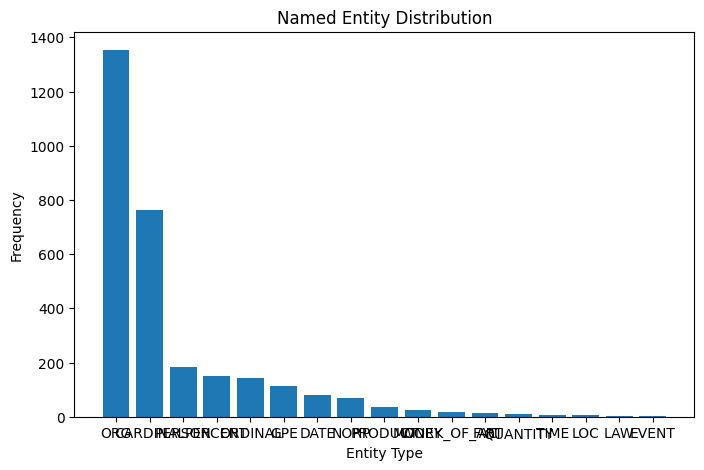

In [26]:
labels, label_counts = zip(*label_freq.most_common())

plt.figure(figsize=(8,5))
plt.bar(labels, label_counts)
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.title("Named Entity Distribution")
plt.show()
